# 09 Model Comparison: LGBM vs XGBoost

This notebook compares the final prediction outputs from 07 and 07_1. It does not train models. It reads baseline and tuned prediction CSVs when they exist, then compares prediction curves, error distributions, bias, category/object behavior, and summary metrics.


## Setup


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config

COMPARISON_DIR = config.TMP_DIR / 'model_comparison'
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)


## Load Available Prediction Files

The comparison only includes files that already exist. If tuned results are missing, rerun 07 or 07_1 with the tuned-parameter switch enabled.


In [2]:
TARGET_MINUTES_LIST = [5.0, 10.0]
SPLIT_TO_COMPARE = 'test'


def horizon_tag(target_minutes):
    return f'{int(target_minutes):02d}min' if float(target_minutes).is_integer() else f'{target_minutes:g}min'.replace('.', 'p')


def result_specs():
    specs = []
    for target_minutes in TARGET_MINUTES_LIST:
        tag = horizon_tag(target_minutes)
        specs.extend([
            {
                'model_family': 'LGBM',
                'model_version': 'LGBM baseline',
                'tuning': 'baseline',
                'target_minutes': target_minutes,
                'path': config.LGBM_HORIZON_COMPARE_DIR / tag / 'lgbm_temperature_predictions.csv',
            },
            {
                'model_family': 'LGBM',
                'model_version': 'LGBM tuned',
                'tuning': 'tuned',
                'target_minutes': target_minutes,
                'path': config.LGBM_HORIZON_COMPARE_DIR / 'tuned' / tag / 'lgbm_temperature_predictions.csv',
            },
            {
                'model_family': 'XGBoost',
                'model_version': 'XGBoost baseline',
                'tuning': 'baseline',
                'target_minutes': target_minutes,
                'path': config.XGBOOST_OUTPUT_DIR / 'horizon_compare' / tag / 'xgboost_temperature_predictions.csv',
            },
            {
                'model_family': 'XGBoost',
                'model_version': 'XGBoost tuned',
                'tuning': 'tuned',
                'target_minutes': target_minutes,
                'path': config.XGBOOST_OUTPUT_DIR / 'horizon_compare' / 'tuned' / tag / 'xgboost_temperature_predictions.csv',
            },
        ])
    return specs


def load_prediction_file(spec):
    path = spec['path']
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df['model_family'] = spec['model_family']
    df['model_version'] = spec['model_version']
    df['tuning'] = spec['tuning']
    df['target_minutes'] = spec['target_minutes']
    if 'timestamp_dt' not in df.columns:
        df['timestamp_dt'] = df['timestamp']
    df['timestamp_dt'] = pd.to_datetime(df['timestamp_dt'])
    df['target_timestamp'] = pd.to_datetime(df['target_timestamp'])
    for column in ['source_temp', 'target_temp', 'prediction', 'error']:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    if 'ci_lower' in df.columns:
        df['ci_lower'] = pd.to_numeric(df['ci_lower'], errors='coerce')
        df['ci_upper'] = pd.to_numeric(df['ci_upper'], errors='coerce')
        df['ci_width'] = df['ci_upper'] - df['ci_lower']
    else:
        df['ci_lower'] = np.nan
        df['ci_upper'] = np.nan
        df['ci_width'] = np.nan
    if 'covered_by_95ci' not in df.columns:
        df['covered_by_95ci'] = np.nan
    return df


load_rows = []
prediction_parts = []
for spec in result_specs():
    loaded = load_prediction_file(spec)
    load_rows.append({
        'model_version': spec['model_version'],
        'target_minutes': spec['target_minutes'],
        'path': str(spec['path']),
        'exists': loaded is not None,
        'rows': 0 if loaded is None else len(loaded),
    })
    if loaded is not None:
        prediction_parts.append(loaded)

load_summary = pd.DataFrame(load_rows)
display(load_summary)

if not prediction_parts:
    raise FileNotFoundError('No prediction CSVs found. Run 07 and 07_1 first.')

all_predictions = pd.concat(prediction_parts, ignore_index=True)
comparison_pred = all_predictions[all_predictions['split'] == SPLIT_TO_COMPARE].copy()
comparison_pred = comparison_pred.dropna(subset=['object_id', 'target_timestamp', 'target_temp', 'prediction', 'error'])
comparison_pred['target_date'] = comparison_pred['target_timestamp'].dt.date
comparison_pred.to_csv(COMPARISON_DIR / 'combined_test_predictions.csv', index=False)

print(f'Combined {SPLIT_TO_COMPARE} prediction rows: {len(comparison_pred):,}')
comparison_pred[['model_version', 'target_minutes', 'object_id', 'target_timestamp', 'target_temp', 'prediction', 'error']].head()


,model_version,target_minutes,path,exists,rows
0,LGBM baseline,5.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55249
1,LGBM tuned,5.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55249
2,XGBoost baseline,5.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55249
3,XGBoost tuned,5.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55249
4,LGBM baseline,10.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55027
5,LGBM tuned,10.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55027
6,XGBoost baseline,10.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55027
7,XGBoost tuned,10.0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True,55027


Combined test prediction rows: 122,500


,model_version,target_minutes,object_id,target_timestamp,target_temp,prediction,error
39899,LGBM baseline,5.0,cableduct_1,2025-04-24 07:06:18,20.768026,20.935311,0.167285
39900,LGBM baseline,5.0,cableduct_1,2025-04-24 07:07:18,20.736496,20.961196,0.224700
39901,LGBM baseline,5.0,cableduct_1,2025-04-24 07:07:18,20.736496,20.945619,0.209123
39902,LGBM baseline,5.0,cableduct_1,2025-04-24 07:07:48,20.703457,20.930749,0.227292
39903,LGBM baseline,5.0,cableduct_1,2025-04-24 07:08:48,20.703279,20.968232,0.264953


## Metric Tables

RMSE and MAE are useful only because these outputs use the same target, horizons, and test dates. They are summary metrics, not the full model judgment.


In [3]:
def summarize_errors(df, group_cols):
    rows = []
    for keys, part in df.groupby(group_cols, sort=True, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        error = part['error'].dropna()
        if error.empty:
            continue
        row = dict(zip(group_cols, keys))
        row.update({
            'rows': len(error),
            'mean_error': error.mean(),
            'median_error': error.median(),
            'mae': error.abs().mean(),
            'rmse': np.sqrt((error ** 2).mean()),
            'p05_error': error.quantile(0.05),
            'p95_error': error.quantile(0.95),
        })
        if part['ci_width'].notna().any():
            row['mean_ci_width'] = part['ci_width'].mean()
            row['ci_coverage'] = part['covered_by_95ci'].mean()
        else:
            row['mean_ci_width'] = np.nan
            row['ci_coverage'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)


model_metrics = summarize_errors(comparison_pred, ['model_version', 'model_family', 'tuning', 'target_minutes'])
category_metrics = summarize_errors(comparison_pred, ['canonical_label', 'model_version', 'target_minutes'])
object_metrics = summarize_errors(comparison_pred, ['object_id', 'canonical_label', 'model_version', 'target_minutes'])

model_metrics.to_csv(COMPARISON_DIR / 'model_metrics.csv', index=False)
category_metrics.to_csv(COMPARISON_DIR / 'category_metrics.csv', index=False)
object_metrics.to_csv(COMPARISON_DIR / 'object_metrics.csv', index=False)

display(model_metrics.sort_values(['target_minutes', 'rmse']))


,model_version,model_family,tuning,target_minutes,rows,mean_error,median_error,mae,rmse,p05_error,p95_error,mean_ci_width,ci_coverage
6,XGBoost tuned,XGBoost,tuned,5.0,15350,0.024699,0.085227,0.297094,0.420094,-0.779086,0.574386,1.552315,0.931010
2,LGBM tuned,LGBM,tuned,5.0,15350,0.043878,0.105487,0.306516,0.424391,-0.772390,0.590271,NaN,NaN
4,XGBoost baseline,XGBoost,baseline,5.0,15350,0.071442,0.140476,0.320956,0.433200,-0.767534,0.608954,1.421974,0.890684
0,LGBM baseline,LGBM,baseline,5.0,15350,0.089728,0.159088,0.328964,0.438166,-0.750881,0.634771,NaN,NaN
7,XGBoost tuned,XGBoost,tuned,10.0,15275,0.041187,0.113015,0.330800,0.451726,-0.830120,0.626640,1.708624,0.924124
3,LGBM tuned,LGBM,tuned,10.0,15275,0.047435,0.121092,0.334526,0.455355,-0.828756,0.638074,NaN,NaN
5,XGBoost baseline,XGBoost,baseline,10.0,15275,0.087439,0.167341,0.359680,0.472051,-0.812329,0.686670,1.521108,0.870442
1,LGBM baseline,LGBM,baseline,10.0,15275,0.105834,0.150082,0.368901,0.493931,-0.784147,0.798076,NaN,NaN


## Prediction Curves

This is the main visual check: can the model follow the ground-truth temperature curve for selected objects and test dates?


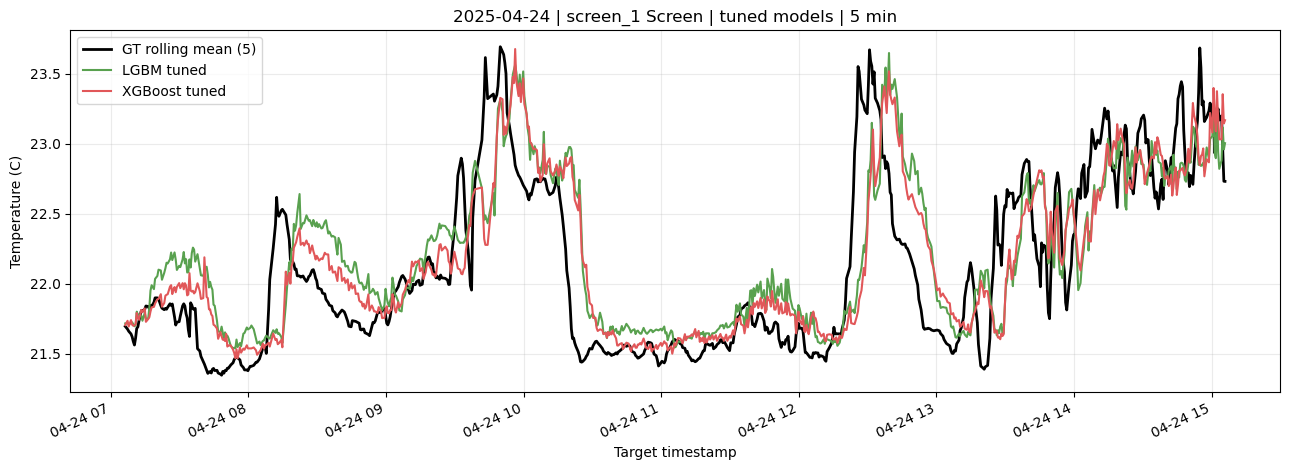

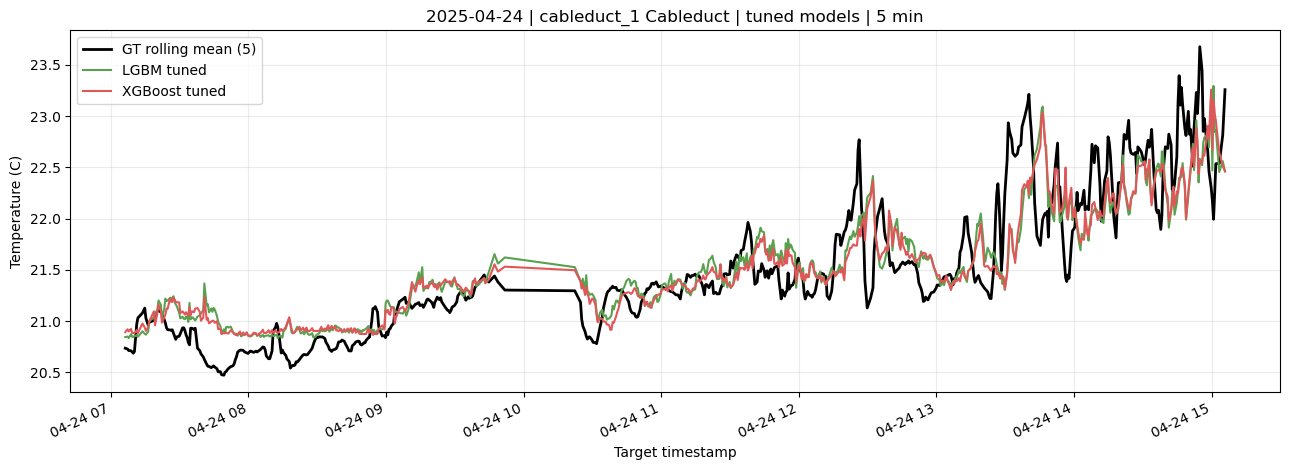

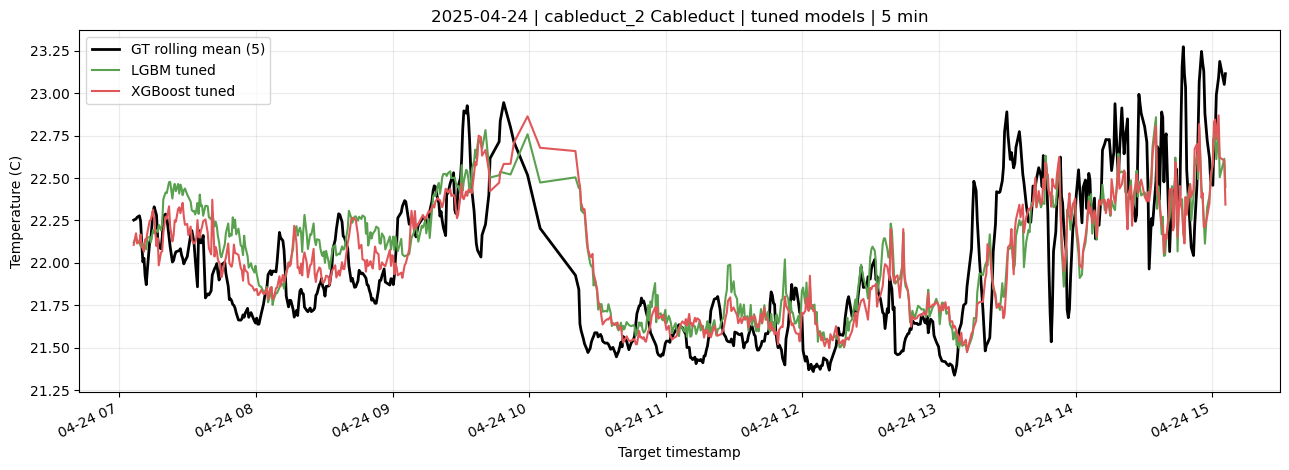

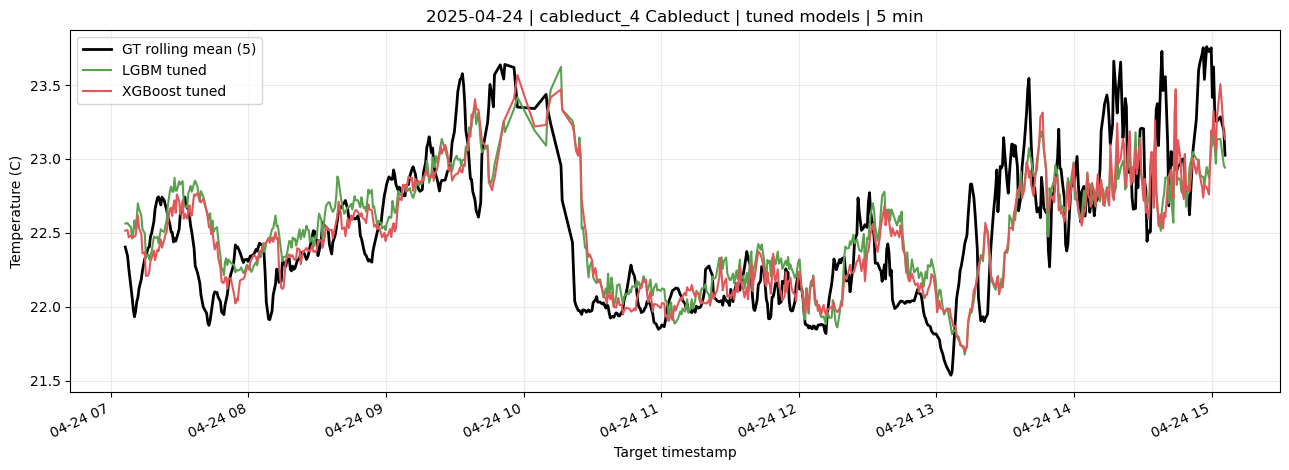

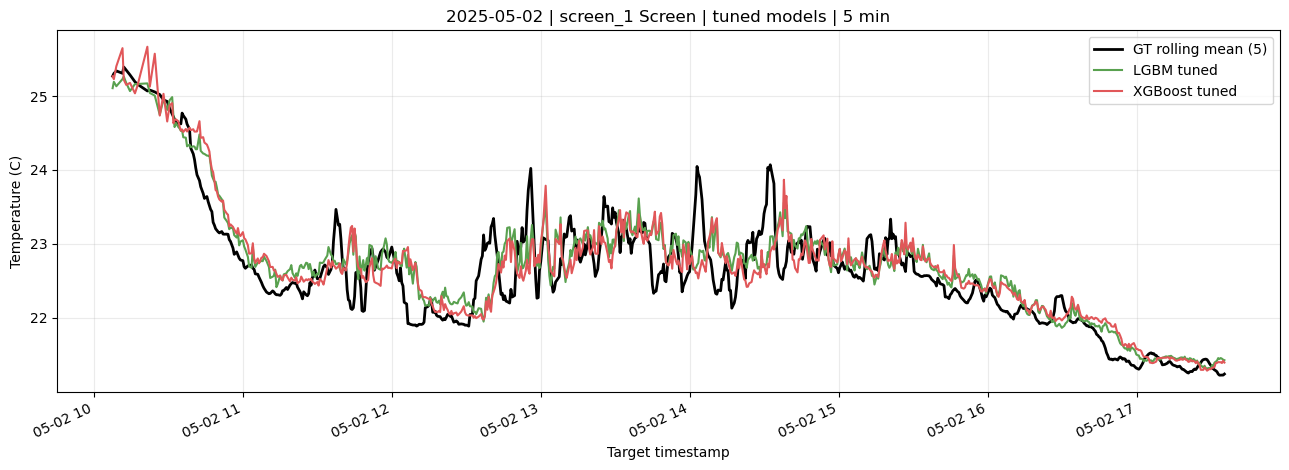

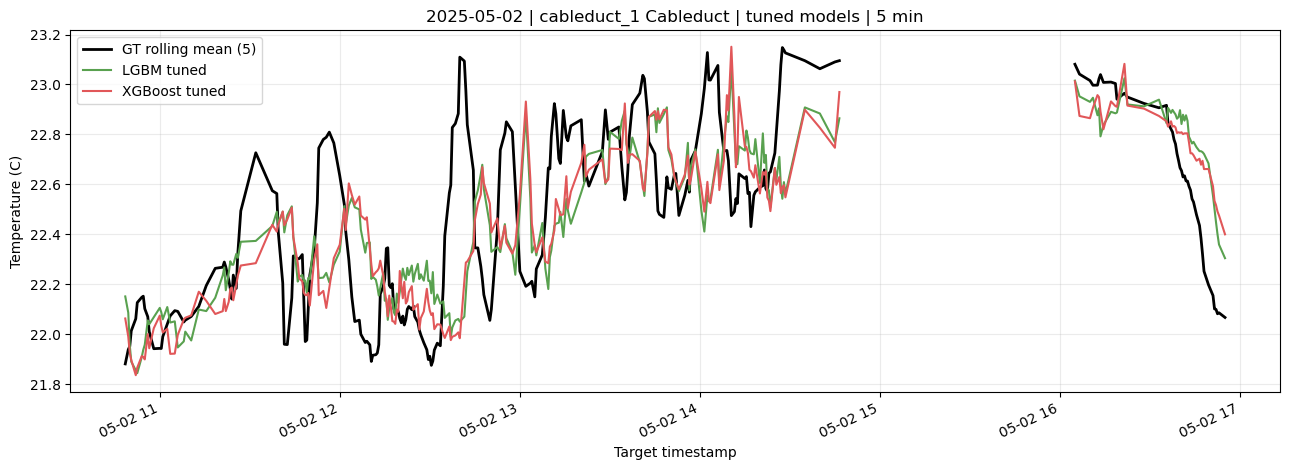

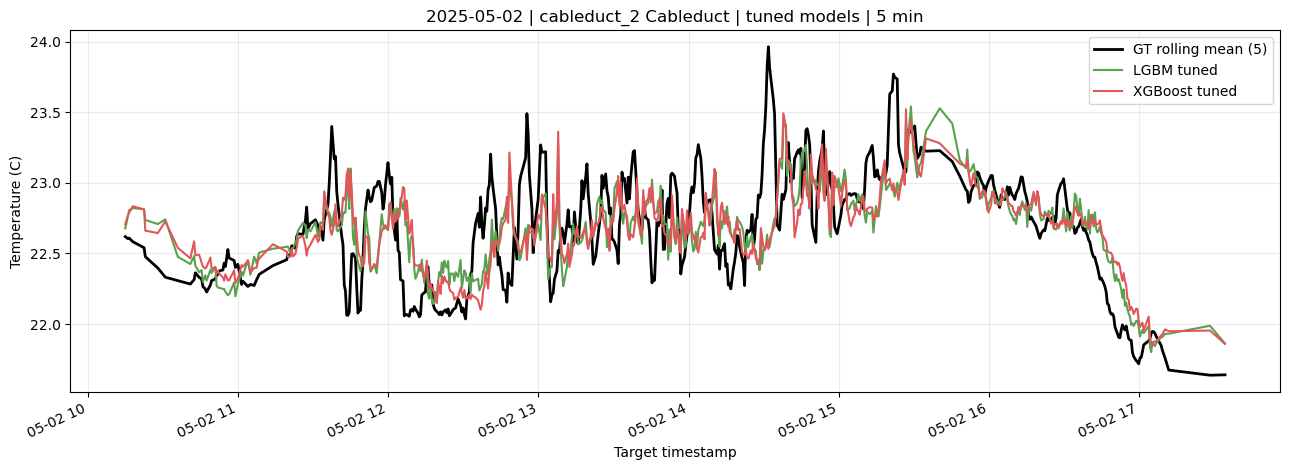

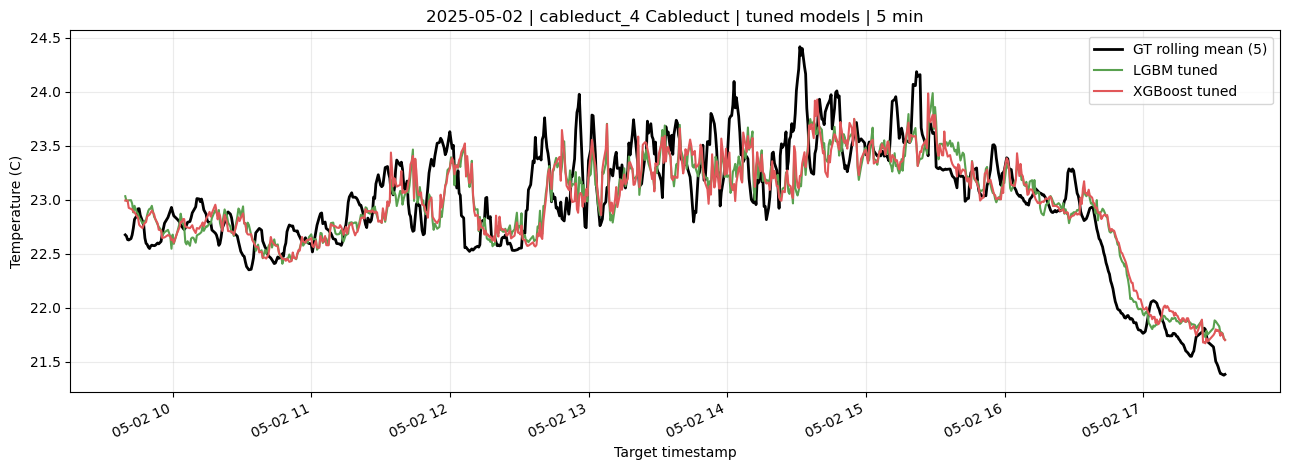

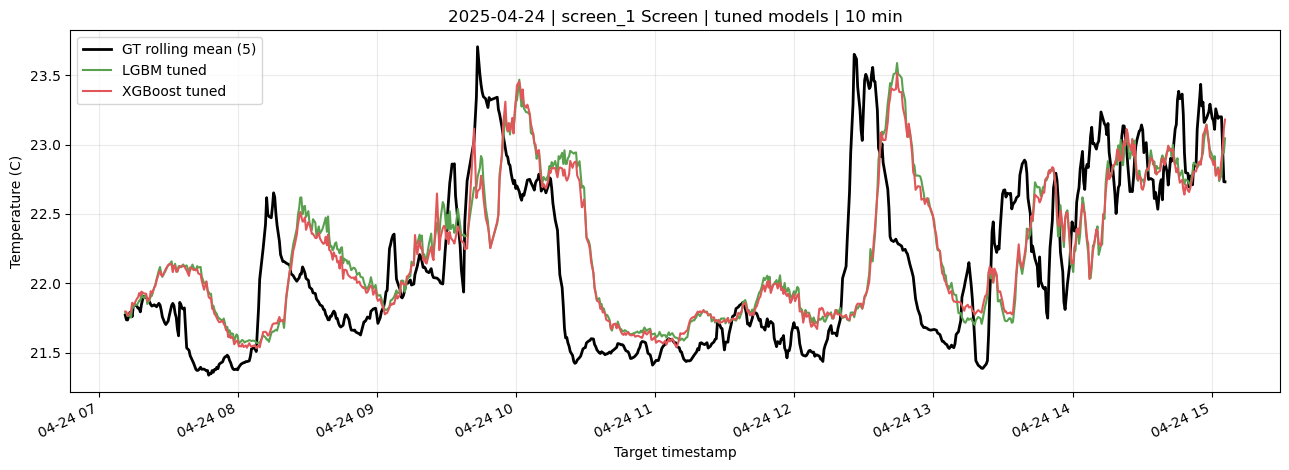

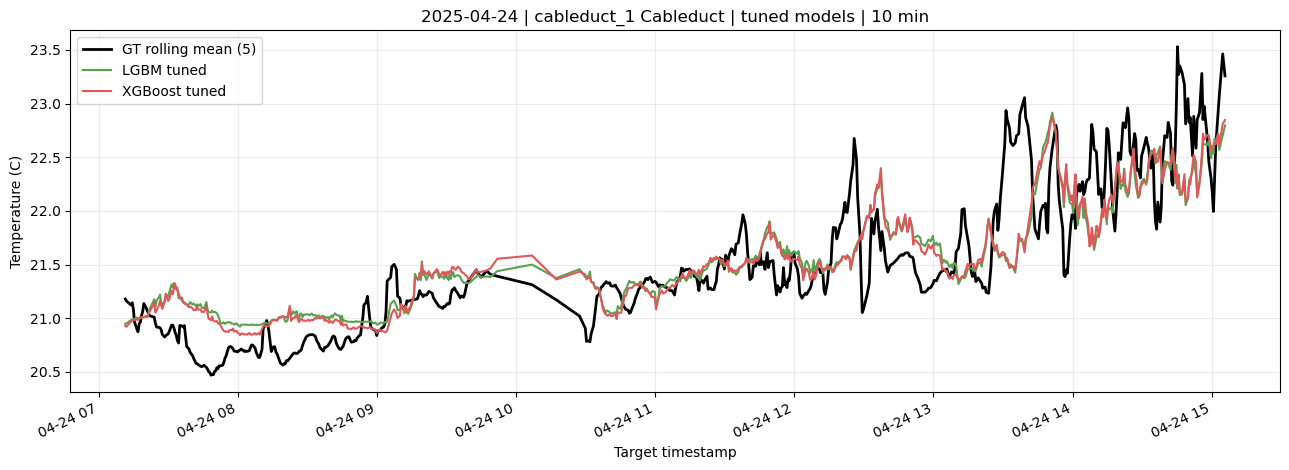

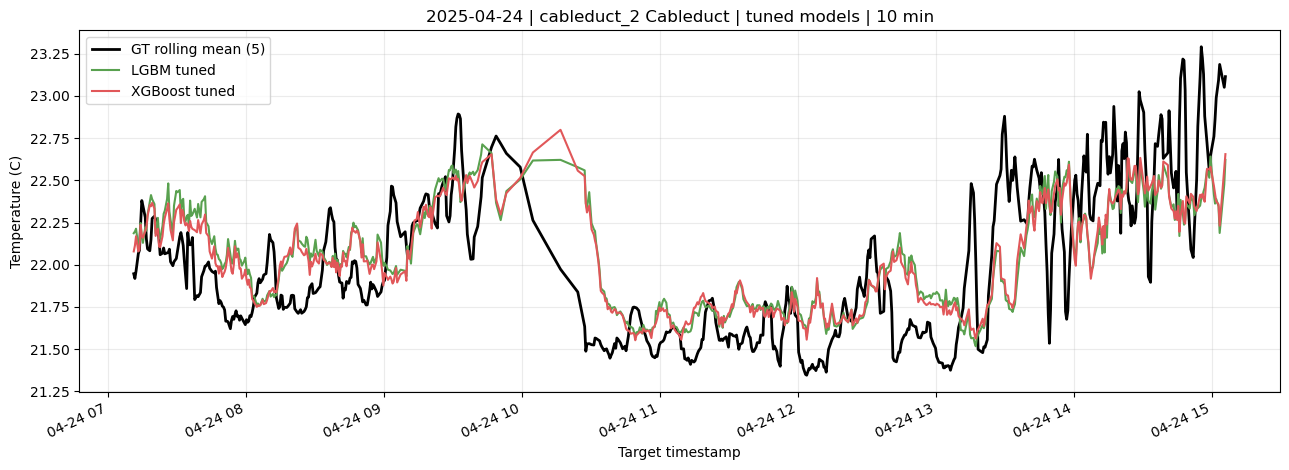

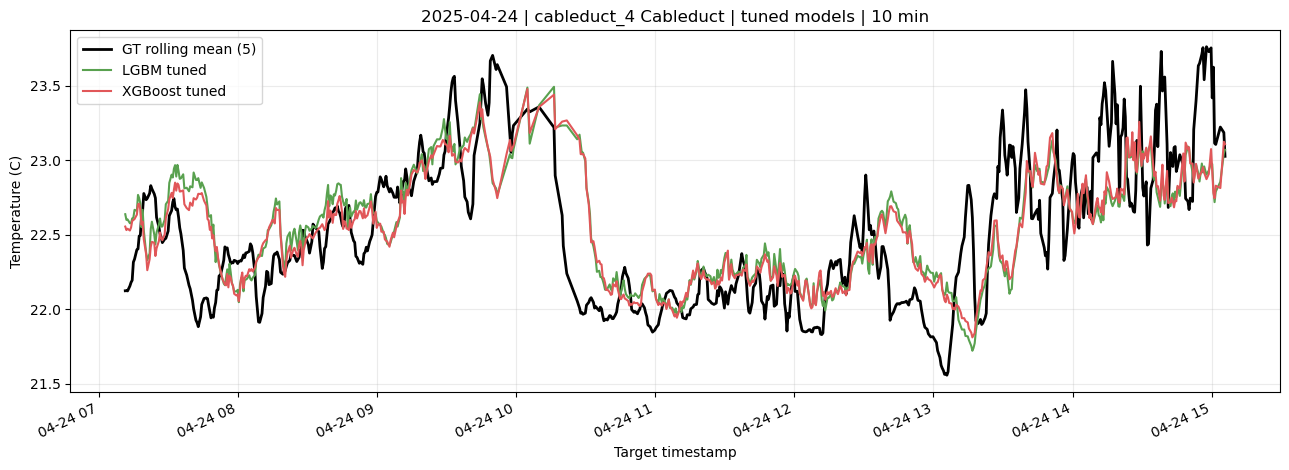

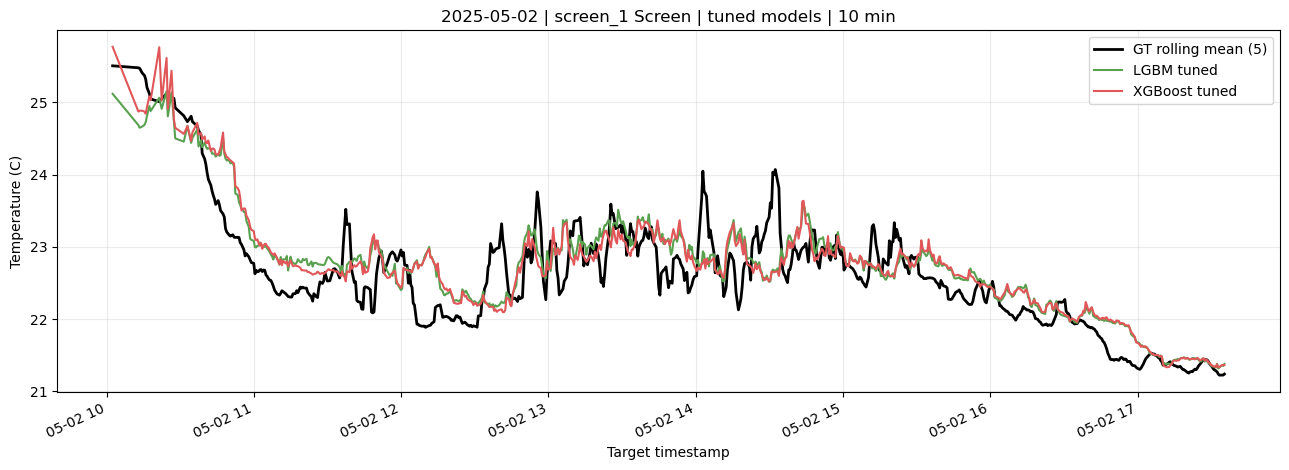

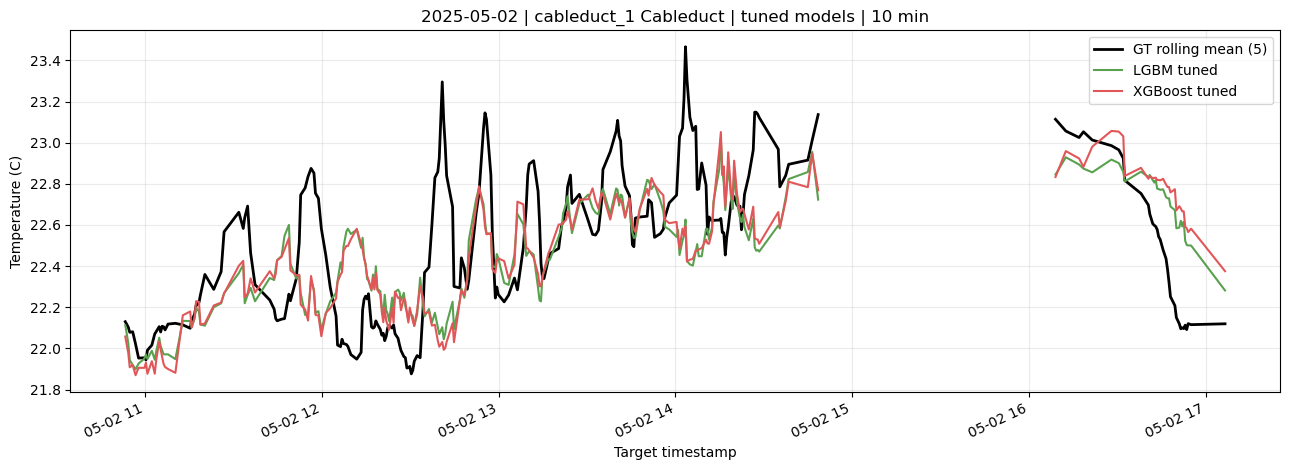

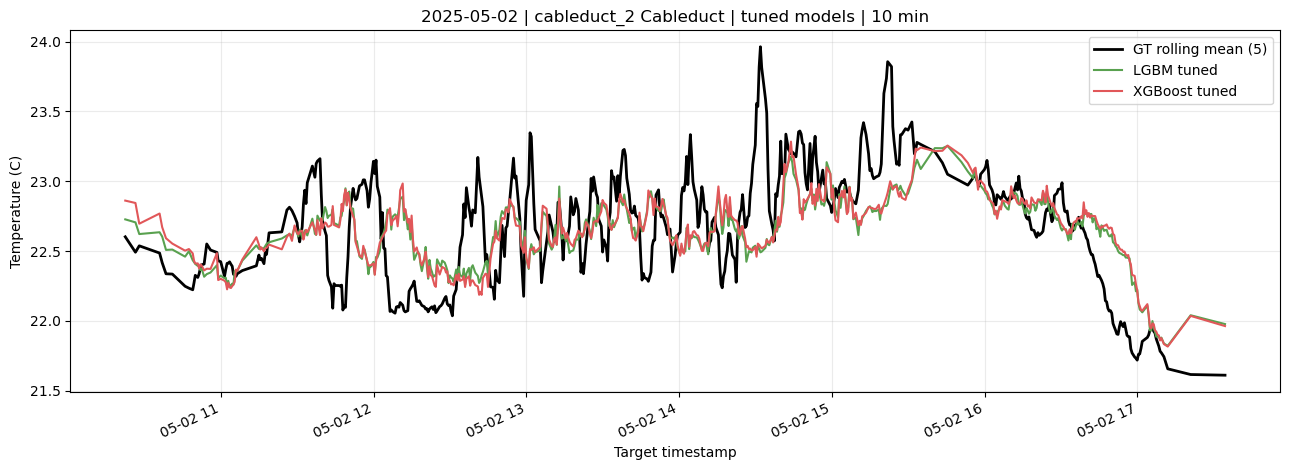

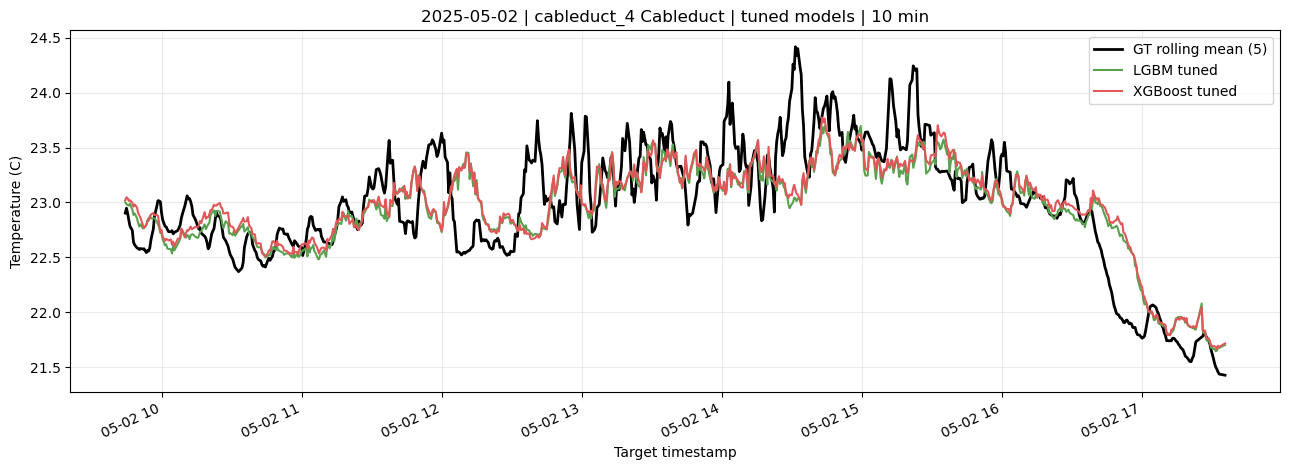

In [4]:
PLOT_OBJECT_IDS = []  # Empty list selects objects with the largest tuned-model average RMSE.
N_OBJECTS_TO_PLOT = 4
PLOT_DATES = []  # Empty list plots all test dates found in the tuned results.
PLOT_TARGET_MINUTES = TARGET_MINUTES_LIST
PLOT_MODEL_VERSIONS = ['LGBM tuned', 'XGBoost tuned']
GT_SMOOTH_WINDOW = 5
MAX_LINE_GAP_MINUTES = 60.0
MAX_POINTS_PER_LINE = None


def add_plot_segments(df, time_col, max_gap_minutes=60.0):
    df = df.sort_values(time_col).copy()
    gap = df[time_col].diff().dt.total_seconds().div(60)
    segment = gap.gt(max_gap_minutes).fillna(False).cumsum()
    return df.assign(_plot_segment=segment)


def downsample_df(df, max_points):
    if max_points is None or len(df) <= max_points:
        return df
    keep_idx = np.linspace(0, len(df) - 1, max_points).astype(int)
    return df.iloc[keep_idx].copy()


def smooth_series(df, value_col='target_temp', output_col='target_temp_plot', window=5):
    df = df.sort_values('target_timestamp').copy()
    if window is None or window <= 1:
        df[output_col] = df[value_col]
    else:
        df[output_col] = df[value_col].rolling(window=window, center=True, min_periods=1).mean()
    return df


curve_pred = comparison_pred[comparison_pred['model_version'].isin(PLOT_MODEL_VERSIONS)].copy()
if curve_pred.empty:
    raise ValueError('No tuned prediction rows found. Rerun 07/07_1 with tuned params enabled first.')

curve_object_metrics = summarize_errors(curve_pred, ['object_id', 'canonical_label', 'model_version', 'target_minutes'])

if PLOT_OBJECT_IDS:
    object_ids_to_plot = PLOT_OBJECT_IDS
else:
    worst_objects = (
        curve_object_metrics.groupby(['object_id', 'canonical_label'], as_index=False)['rmse']
        .mean()
        .sort_values('rmse', ascending=False)
    )
    object_ids_to_plot = worst_objects['object_id'].head(N_OBJECTS_TO_PLOT).tolist()

dates_to_plot = sorted(curve_pred['target_date'].unique()) if not PLOT_DATES else [pd.to_datetime(d).date() for d in PLOT_DATES]
model_colors = {
    'LGBM tuned': '#59a14f',
    'XGBoost tuned': '#e15759',
}

for target_minutes in PLOT_TARGET_MINUTES:
    horizon_df = curve_pred[curve_pred['target_minutes'] == target_minutes].copy()
    for target_date in dates_to_plot:
        day_df = horizon_df[horizon_df['target_date'] == target_date].copy()
        if day_df.empty:
            continue
        for object_id in object_ids_to_plot:
            object_day = day_df[day_df['object_id'] == object_id].copy()
            if object_day.empty:
                continue
            label = object_day['canonical_label'].mode().iloc[0] if not object_day['canonical_label'].mode().empty else ''

            gt_df = (
                object_day[['target_timestamp', 'target_temp']]
                .drop_duplicates()
                .groupby('target_timestamp', as_index=False)['target_temp']
                .median()
            )
            gt_df = smooth_series(gt_df, value_col='target_temp', output_col='target_temp_plot', window=GT_SMOOTH_WINDOW)
            gt_df = downsample_df(add_plot_segments(gt_df, 'target_timestamp', MAX_LINE_GAP_MINUTES), MAX_POINTS_PER_LINE)

            plot_pred = (
                object_day
                .groupby(['model_version', 'target_timestamp'], as_index=False)
                .agg(prediction=('prediction', 'median'))
            )

            fig, ax = plt.subplots(figsize=(13, 4.8))
            for segment_id, segment in gt_df.groupby('_plot_segment'):
                ax.plot(
                    segment['target_timestamp'],
                    segment['target_temp_plot'],
                    color='black',
                    linewidth=2.0,
                    label=f'GT rolling mean ({GT_SMOOTH_WINDOW})' if segment_id == gt_df['_plot_segment'].min() else None,
                )

            for model_version, model_df in plot_pred.groupby('model_version'):
                model_df = downsample_df(add_plot_segments(model_df, 'target_timestamp', MAX_LINE_GAP_MINUTES), MAX_POINTS_PER_LINE)
                first_segment = model_df['_plot_segment'].min()
                for segment_id, segment in model_df.groupby('_plot_segment'):
                    ax.plot(
                        segment['target_timestamp'],
                        segment['prediction'],
                        linewidth=1.5,
                        color=model_colors.get(model_version),
                        label=model_version if segment_id == first_segment else None,
                    )

            ax.set_title(f'{target_date} | {object_id} {label} | tuned models | {target_minutes:g} min')
            ax.set_xlabel('Target timestamp')
            ax.set_ylabel('Temperature (C)')
            ax.grid(alpha=0.25)
            ax.legend(loc='best')
            fig.autofmt_xdate(rotation=25)
            fig.tight_layout()


## Error Distribution

This shows bias shape and long tails. A good model should be centered near zero with fewer extreme errors.


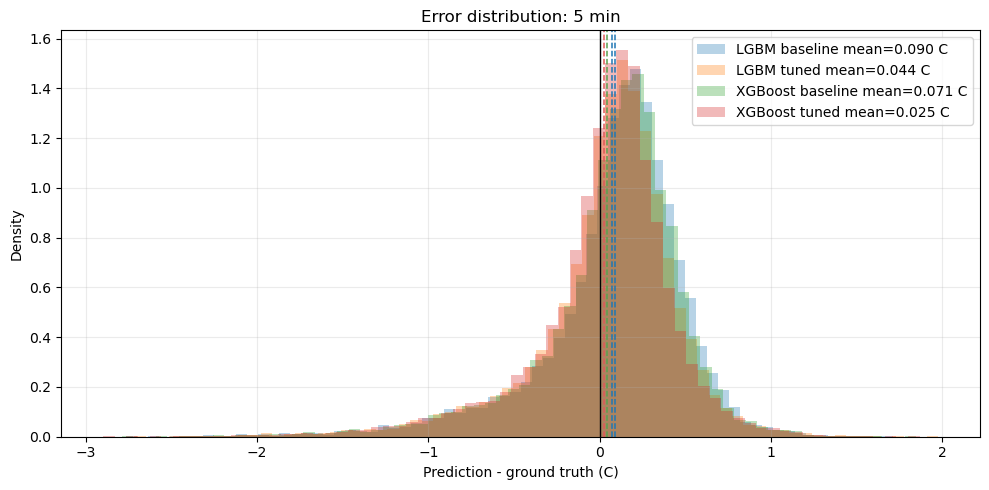

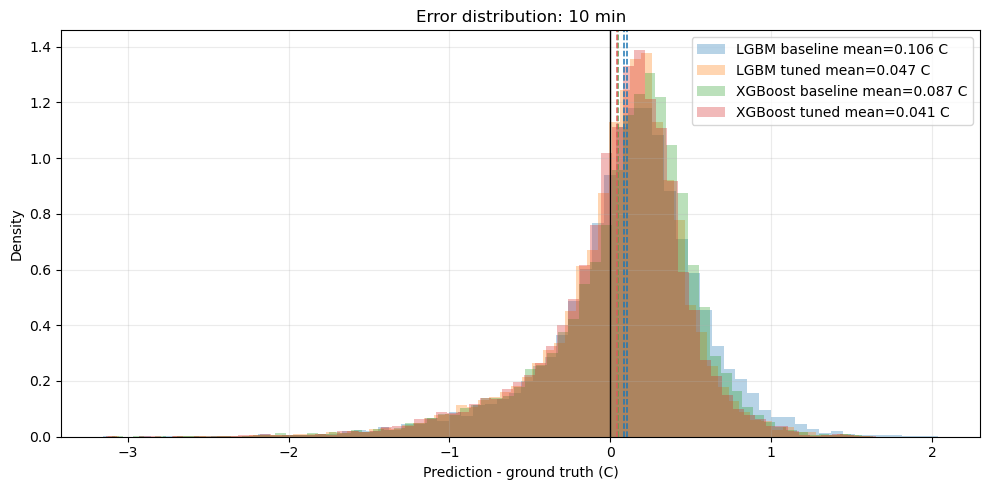

In [5]:
ERROR_BINS = 70
for target_minutes in TARGET_MINUTES_LIST:
    part_h = comparison_pred[comparison_pred['target_minutes'] == target_minutes].copy()
    if part_h.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_version, part in part_h.groupby('model_version'):
        errors = part['error'].dropna()
        if errors.empty:
            continue
        ax.hist(errors, bins=ERROR_BINS, alpha=0.32, density=True, label=f'{model_version} mean={errors.mean():.3f} C')
        ax.axvline(errors.mean(), color=model_colors.get(model_version), linestyle='--', linewidth=1.1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Error distribution: {target_minutes:g} min')
    ax.set_xlabel('Prediction - ground truth (C)')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()


## Bias Summary

Mean error shows systematic over-prediction or under-prediction. Positive means prediction is hotter than ground truth.


target_minutes,5.0,10.0
model_version,,
LGBM baseline,0.089728,0.105834
LGBM tuned,0.043878,0.047435
XGBoost baseline,0.071442,0.087439
XGBoost tuned,0.024699,0.041187


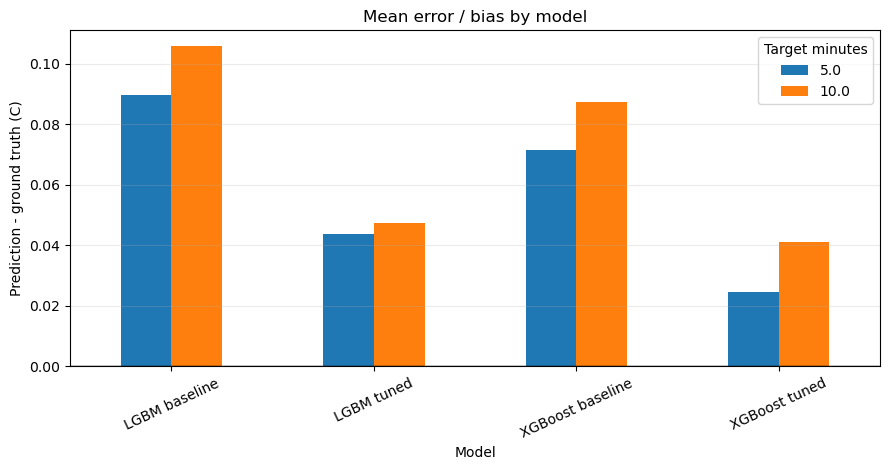

In [6]:
bias_pivot = model_metrics.pivot_table(index='model_version', columns='target_minutes', values='mean_error')
display(bias_pivot)

fig, ax = plt.subplots(figsize=(9, 4.8))
bias_pivot.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Mean error / bias by model')
ax.set_xlabel('Model')
ax.set_ylabel('Prediction - ground truth (C)')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Target minutes')
fig.tight_layout()


## Category-Level Error

This checks whether one model only works well for certain object categories.


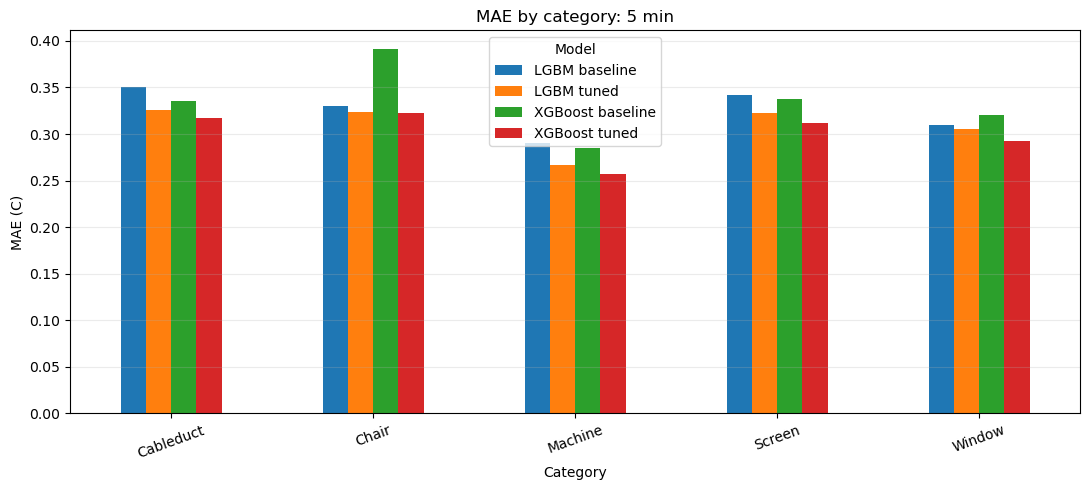

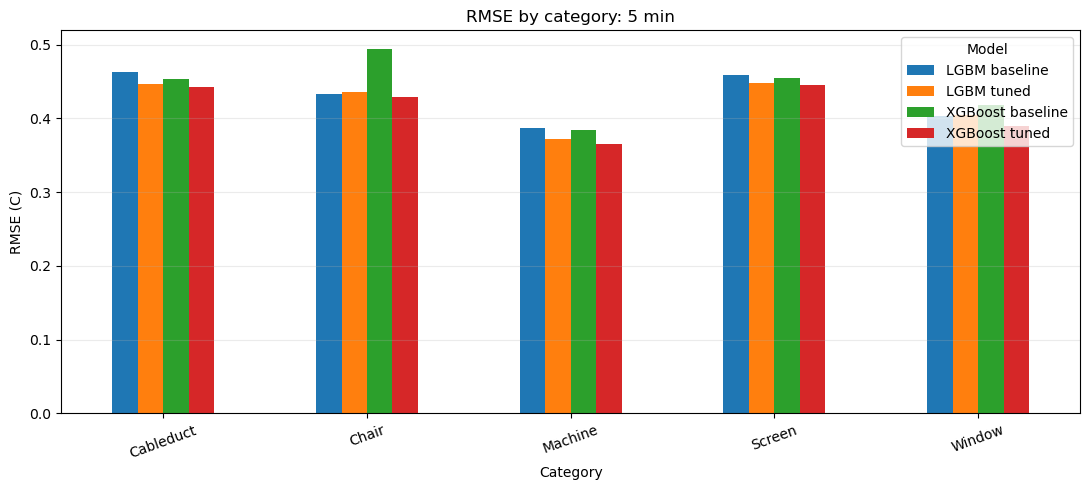

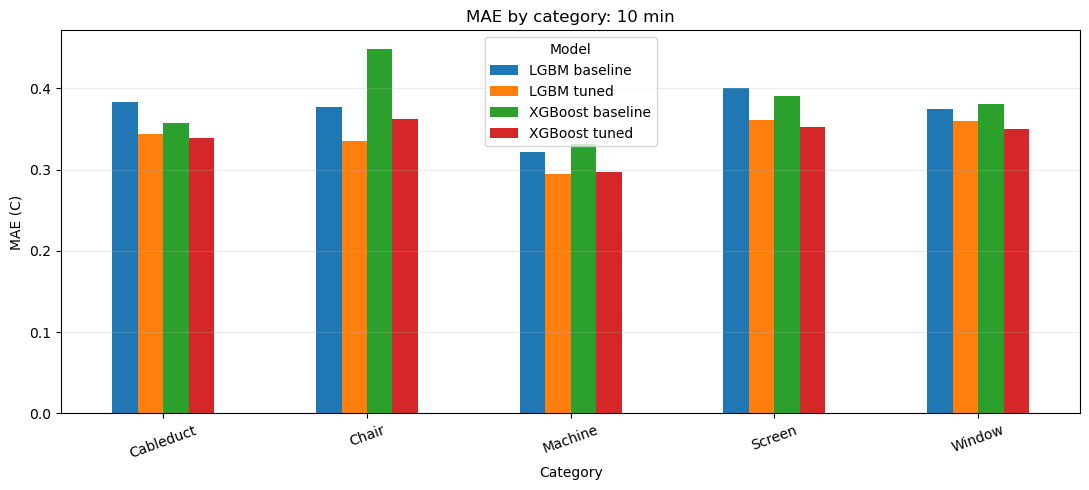

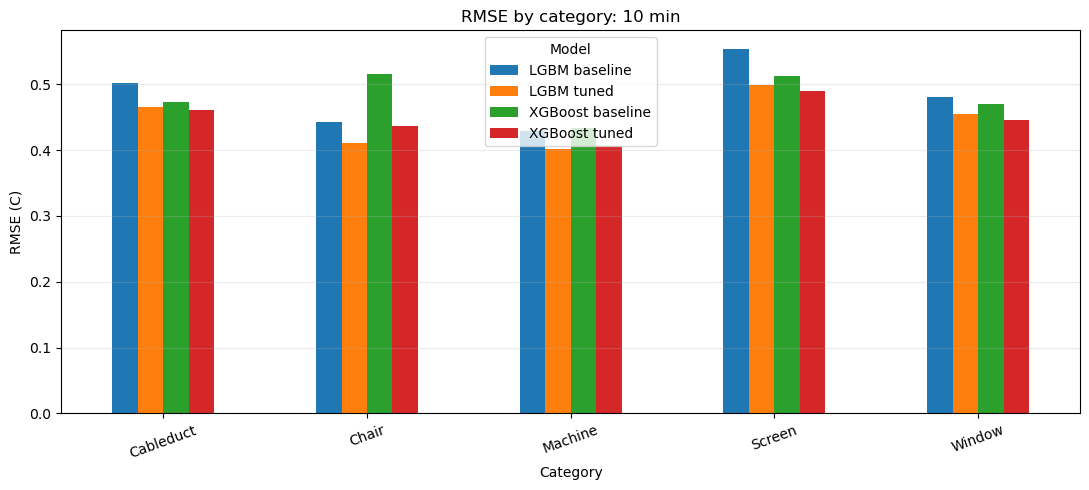

In [7]:
for target_minutes in TARGET_MINUTES_LIST:
    part = category_metrics[category_metrics['target_minutes'] == target_minutes].copy()
    if part.empty:
        continue
    for metric in ['mae', 'rmse']:
        pivot = part.pivot_table(index='canonical_label', columns='model_version', values=metric)
        fig, ax = plt.subplots(figsize=(11, 5))
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(f'{metric.upper()} by category: {target_minutes:g} min')
        ax.set_xlabel('Category')
        ax.set_ylabel(f'{metric.upper()} (C)')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(axis='y', alpha=0.25)
        ax.legend(title='Model')
        fig.tight_layout()


## Worst Objects

This finds objects that remain difficult across models. These are usually more actionable than the overall average.


,object_id,canonical_label,avg_rmse,avg_mae,avg_abs_bias,rows
10,screen_1,Screen,0.542056,0.416486,0.134699,14500
0,cableduct_1,Cableduct,0.493651,0.368201,0.048057,9884
1,cableduct_2,Cableduct,0.478074,0.357356,0.050840,12684
3,cableduct_4,Cableduct,0.472808,0.345947,0.023106,14588
4,chair_1,Chair,0.449664,0.361392,0.168736,1060
12,window_1,Window,0.433382,0.336895,0.038190,5168
6,machine_2,Machine,0.431660,0.303792,0.060462,11336
2,cableduct_3,Cableduct,0.415263,0.312827,0.036626,14064
11,screen_2,Screen,0.414926,0.289187,0.068990,14772
9,machine_6,Machine,0.409036,0.304806,0.059883,12844


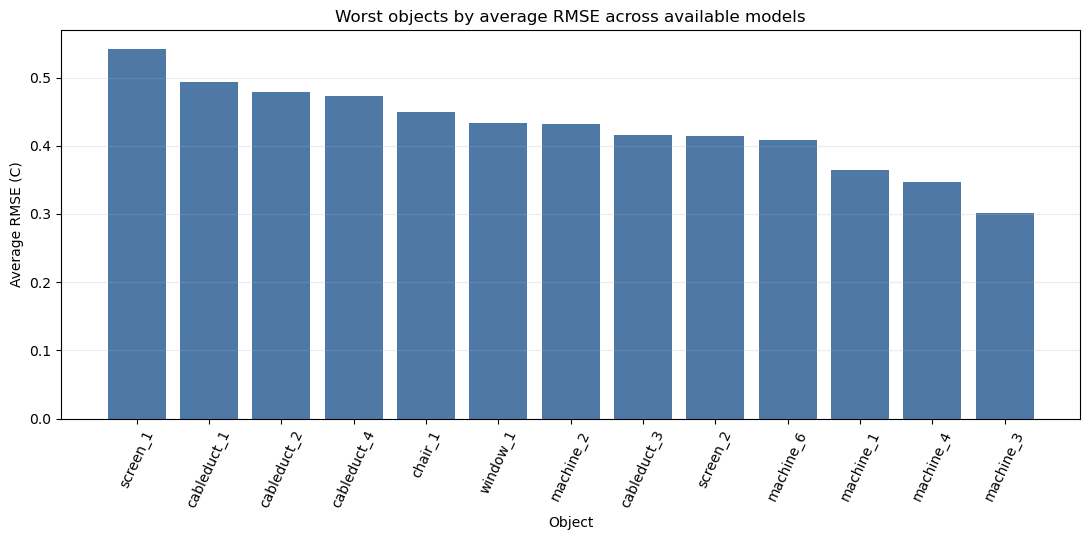

In [8]:
WORST_OBJECT_TOP_N = 15
worst_object_summary = (
    object_metrics
    .groupby(['object_id', 'canonical_label'], as_index=False)
    .agg(avg_rmse=('rmse', 'mean'), avg_mae=('mae', 'mean'), avg_abs_bias=('mean_error', lambda s: s.abs().mean()), rows=('rows', 'sum'))
    .sort_values('avg_rmse', ascending=False)
)
display(worst_object_summary.head(WORST_OBJECT_TOP_N))

plot_worst = worst_object_summary.head(WORST_OBJECT_TOP_N).copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(plot_worst['object_id'], plot_worst['avg_rmse'], color='#4e79a7')
ax.set_title('Worst objects by average RMSE across available models')
ax.set_xlabel('Object')
ax.set_ylabel('Average RMSE (C)')
ax.tick_params(axis='x', rotation=65)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()


## Object-Level Model Comparison

Use this when a specific object matters more than the global average.


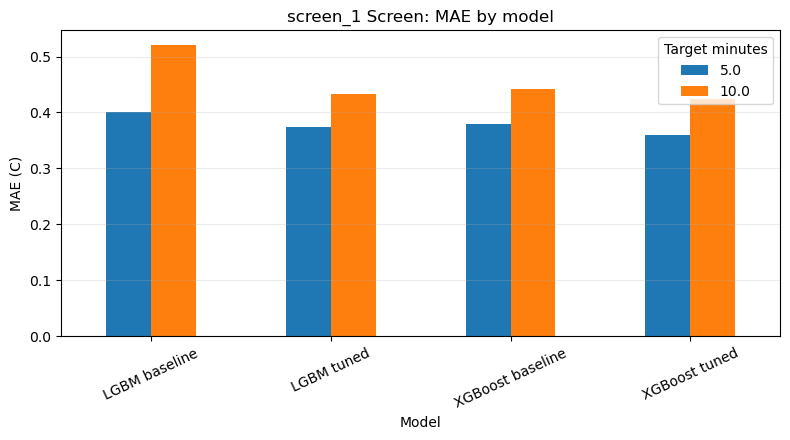

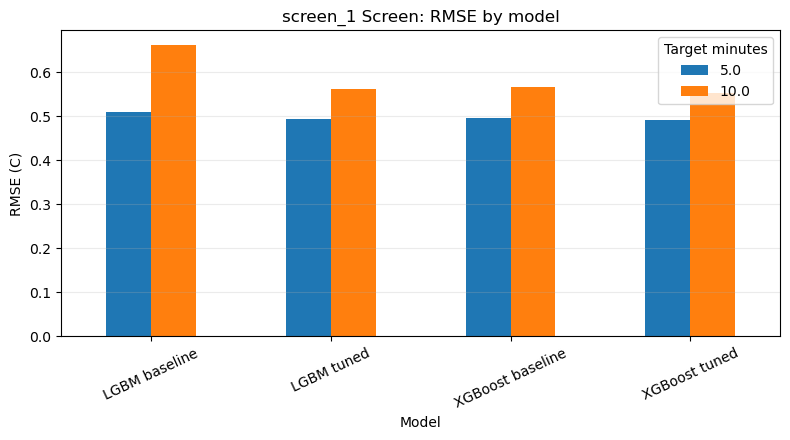

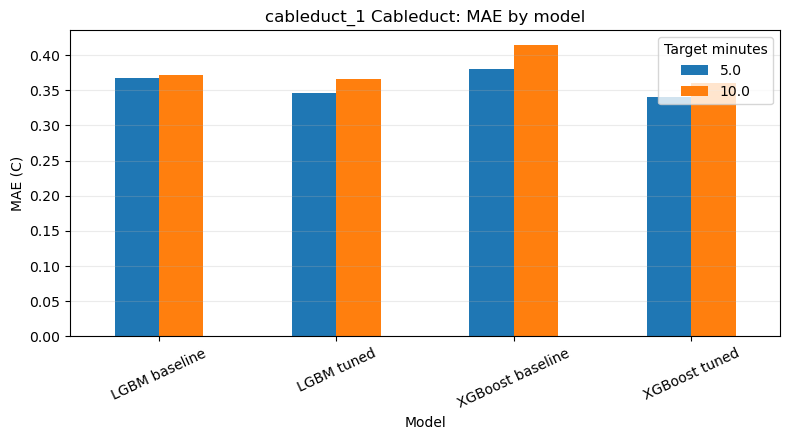

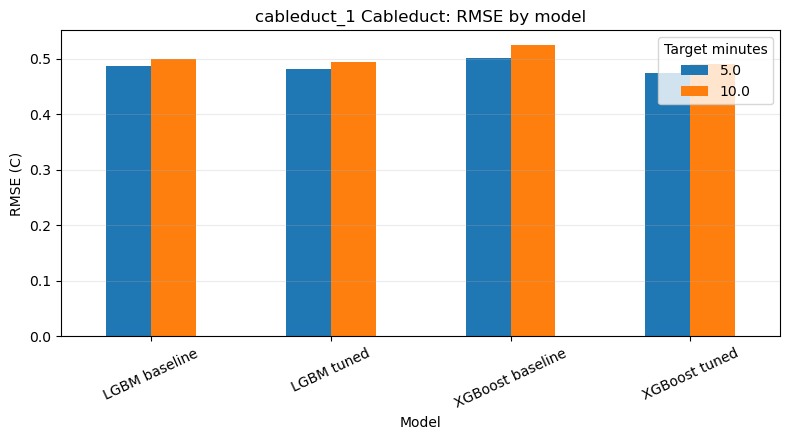

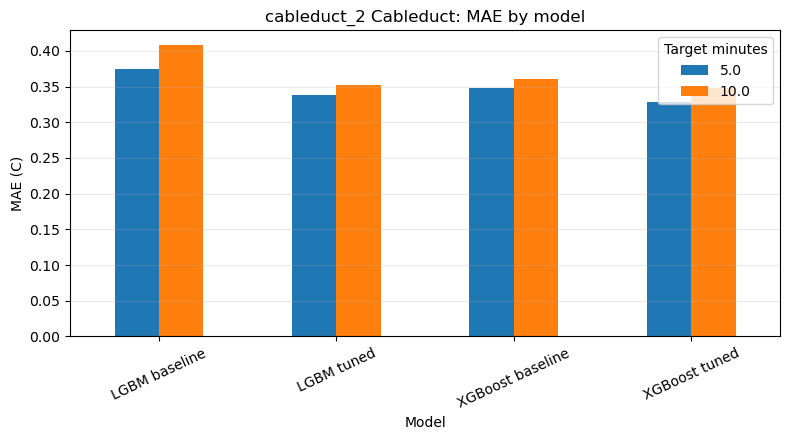

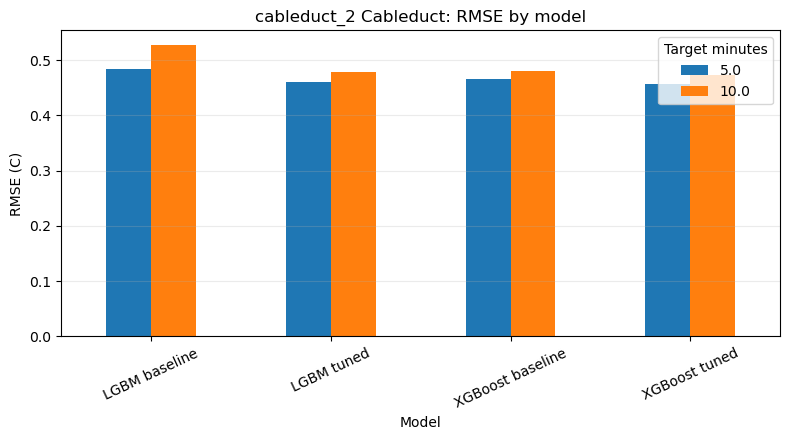

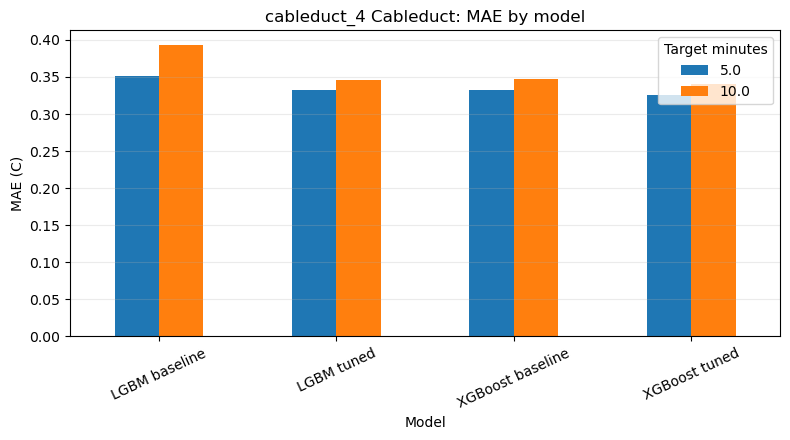

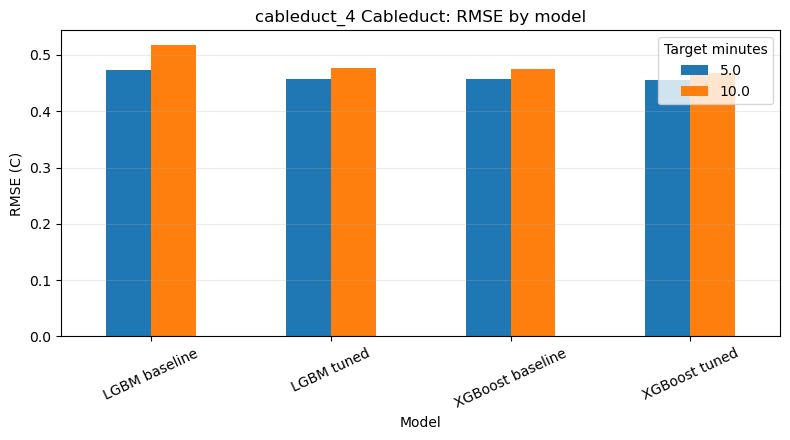

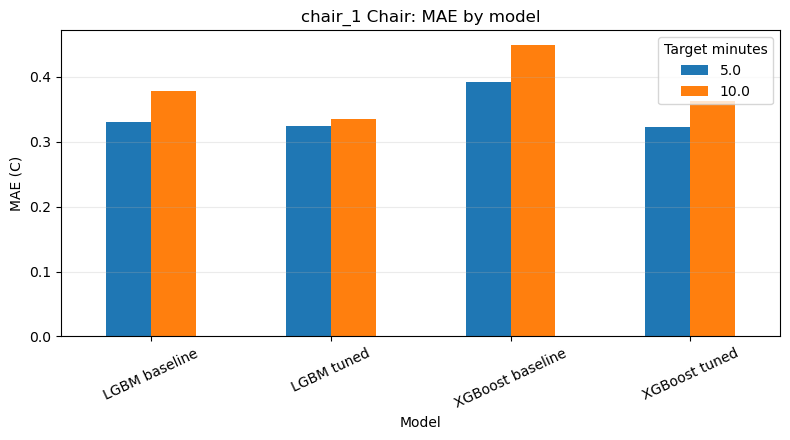

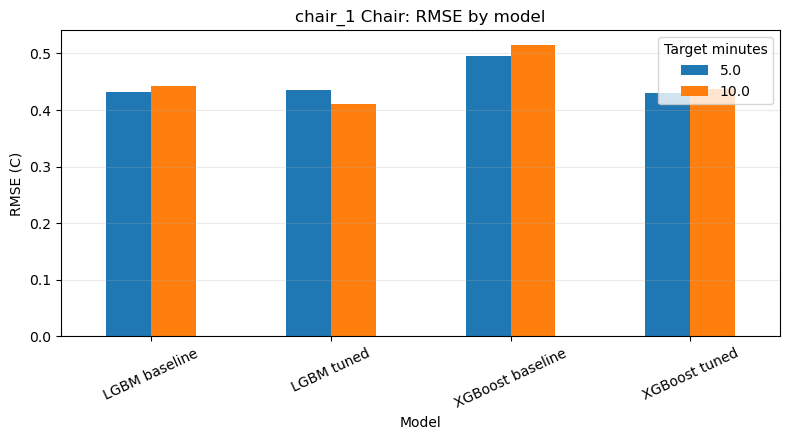

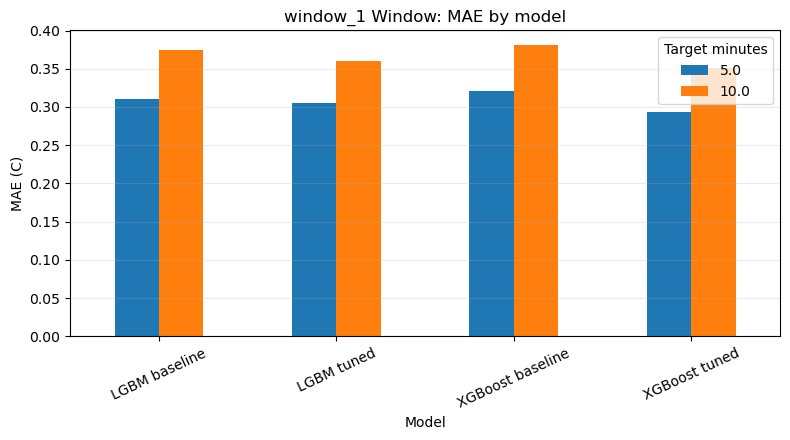

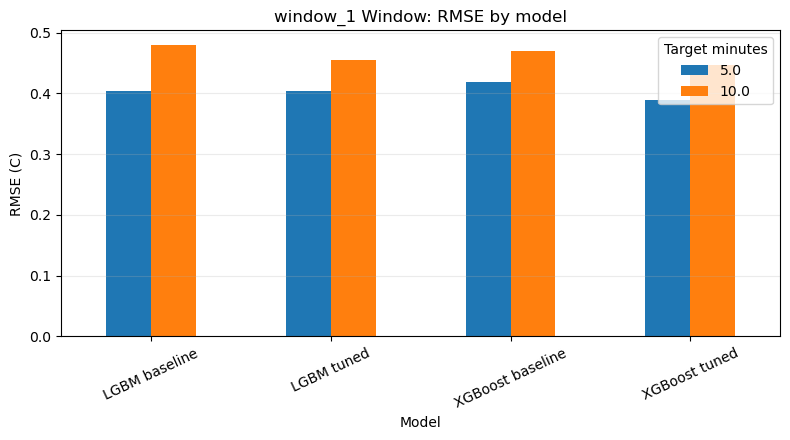

In [9]:
OBJECT_COMPARE_IDS = []  # Example: ['cableduct_2', 'screen_2']. Empty list uses worst objects above.
OBJECT_COMPARE_TOP_N = 6

objects_to_compare = OBJECT_COMPARE_IDS or worst_object_summary['object_id'].head(OBJECT_COMPARE_TOP_N).tolist()
for object_id in objects_to_compare:
    part = object_metrics[object_metrics['object_id'] == object_id].copy()
    if part.empty:
        continue
    label = part['canonical_label'].mode().iloc[0] if not part['canonical_label'].mode().empty else ''
    for metric in ['mae', 'rmse']:
        pivot = part.pivot_table(index='model_version', columns='target_minutes', values=metric)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(f'{object_id} {label}: {metric.upper()} by model')
        ax.set_xlabel('Model')
        ax.set_ylabel(f'{metric.upper()} (C)')
        ax.tick_params(axis='x', rotation=25)
        ax.grid(axis='y', alpha=0.25)
        ax.legend(title='Target minutes')
        fig.tight_layout()


## RMSE / MAE Summary

This is a compact numeric summary. It is useful after checking curves and distributions, not as the only decision rule.


target_minutes,5.0,10.0
model_version,,
XGBoost tuned,0.297094,0.330800
LGBM tuned,0.306516,0.334526
XGBoost baseline,0.320956,0.359680
LGBM baseline,0.328964,0.368901


target_minutes,5.0,10.0
model_version,,
XGBoost tuned,0.420094,0.451726
LGBM tuned,0.424391,0.455355
XGBoost baseline,0.433200,0.472051
LGBM baseline,0.438166,0.493931


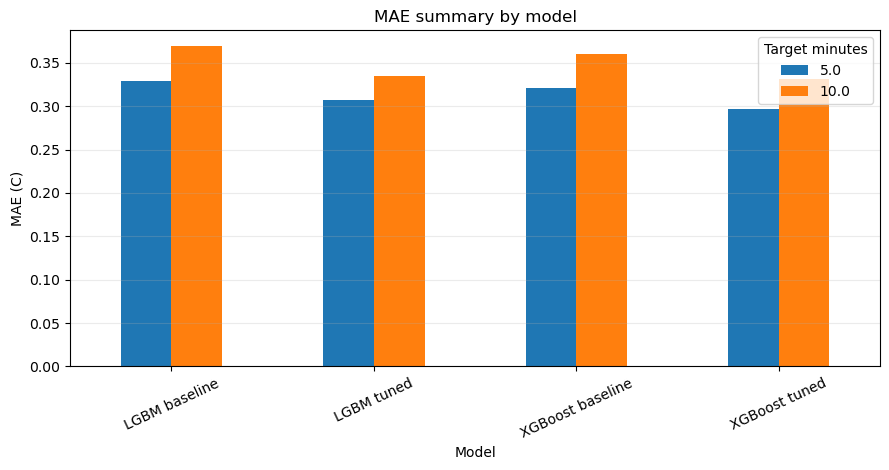

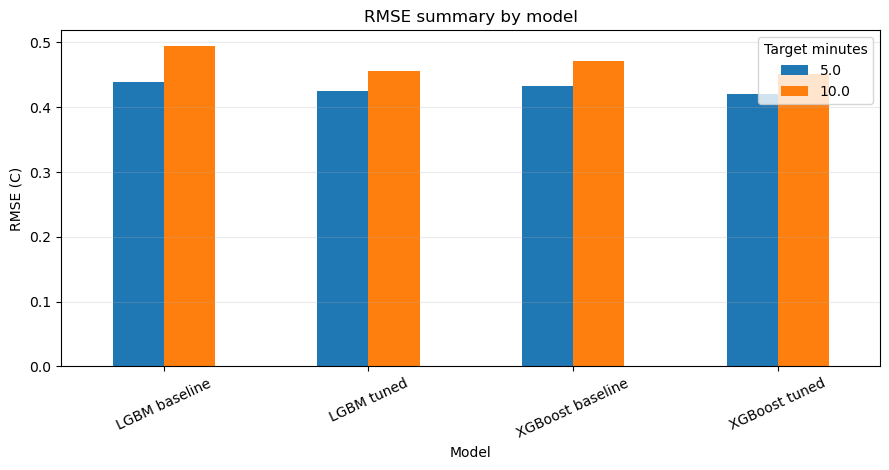

In [10]:
for metric in ['mae', 'rmse']:
    pivot = model_metrics.pivot_table(index='model_version', columns='target_minutes', values=metric)
    display(pivot.sort_values(TARGET_MINUTES_LIST[0] if TARGET_MINUTES_LIST[0] in pivot.columns else pivot.columns[0]))
    fig, ax = plt.subplots(figsize=(9, 4.8))
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{metric.upper()} summary by model')
    ax.set_xlabel('Model')
    ax.set_ylabel(f'{metric.upper()} (C)')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title='Target minutes')
    fig.tight_layout()


## CI Diagnostics

XGBoost prediction CSVs include quantile-model CI columns. LGBM prediction CSVs do not store the empirical CI bands from 07, so CI comparison here is only complete for XGBoost.


,model_version,target_minutes,mean_ci_width,ci_coverage,rmse,mae
0,XGBoost baseline,5.0,1.421974,0.890684,0.433200,0.320956
1,XGBoost baseline,10.0,1.521108,0.870442,0.472051,0.359680
2,XGBoost tuned,5.0,1.552315,0.931010,0.420094,0.297094
3,XGBoost tuned,10.0,1.708624,0.924124,0.451726,0.330800


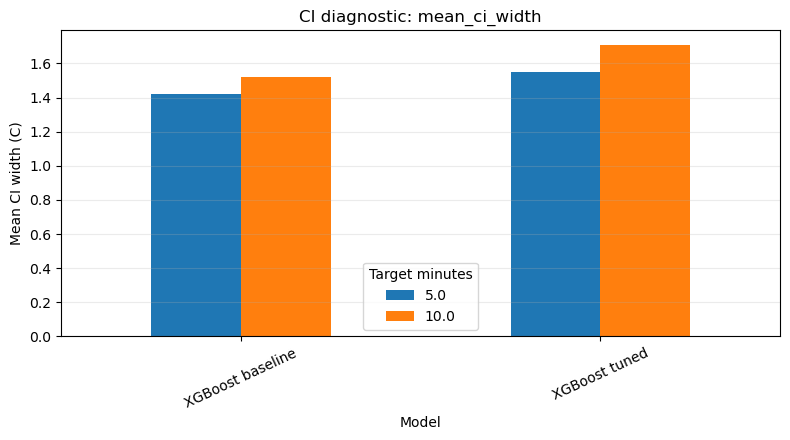

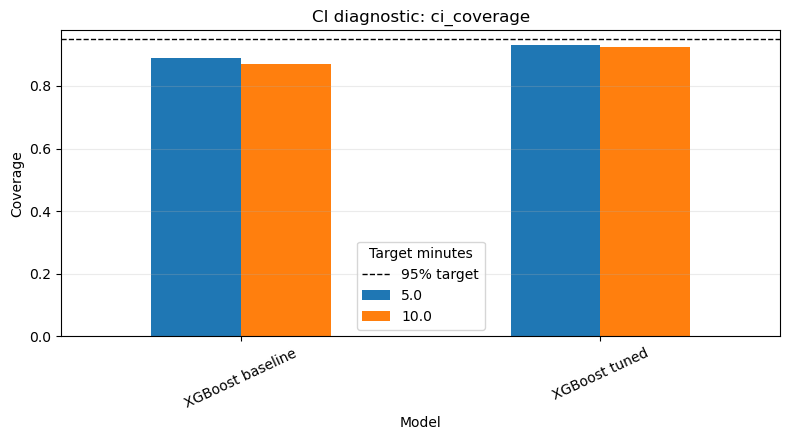

In [11]:
ci_available = comparison_pred[comparison_pred['ci_width'].notna()].copy()
if ci_available.empty:
    print('No CI columns available in the loaded prediction CSVs.')
else:
    ci_metrics = summarize_errors(ci_available, ['model_version', 'target_minutes'])
    display(ci_metrics[['model_version', 'target_minutes', 'mean_ci_width', 'ci_coverage', 'rmse', 'mae']])

    for metric, ylabel in [('mean_ci_width', 'Mean CI width (C)'), ('ci_coverage', 'Coverage')]:
        pivot = ci_metrics.pivot_table(index='model_version', columns='target_minutes', values=metric)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        pivot.plot(kind='bar', ax=ax)
        if metric == 'ci_coverage':
            ax.axhline(0.95, color='black', linestyle='--', linewidth=1, label='95% target')
        ax.set_title(f'CI diagnostic: {metric}')
        ax.set_xlabel('Model')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(axis='y', alpha=0.25)
        ax.legend(title='Target minutes')
        fig.tight_layout()


## Saved Comparison Files


In [12]:
saved_files = [
    COMPARISON_DIR / 'combined_test_predictions.csv',
    COMPARISON_DIR / 'model_metrics.csv',
    COMPARISON_DIR / 'category_metrics.csv',
    COMPARISON_DIR / 'object_metrics.csv',
]
pd.DataFrame({'path': [str(path) for path in saved_files], 'exists': [path.exists() for path in saved_files]})


,path,exists
0,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True
1,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True
2,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True
3,/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/20...,True
